In [23]:
# Imports
import sys
sys.path.append('../../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sentence_transformers import SentenceTransformer
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [24]:
from src.preprocessing.clean_data import load_and_clean

df = pd.read_csv('../../data/processed/WineDataset_clean.csv')
print(f"Shape: {df.shape}")

Shape: (1286, 12)


In [25]:
# Load embedding model
print("Loading embedding model...")
model = SentenceTransformer('Qwen/Qwen3-Embedding-0.6B')

# Generate embeddings for Description column
print("Generating embeddings... (poate dura cateva minute)")
embeddings = model.encode(df['Description'].tolist(), show_progress_bar=True)

print(f"Embeddings shape: {embeddings.shape}")

Loading embedding model...


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Generating embeddings... (poate dura cateva minute)


Batches:   0%|          | 0/41 [00:00<?, ?it/s]

Embeddings shape: (1286, 1024)


In [30]:
# Define features
cat_cols = ['Capacity', 'Grape', 'Closure', 'Country', 'Type', 'Region', 'Style', 'Vintage']
num_cols = ['ABV']
target = 'Price_log'

X_tab = df[cat_cols + num_cols]
y = df[target]

# Train/test split — same random_state as baseline for fair comparison!
X_train_idx, X_test_idx = train_test_split(df.index, test_size=0.2, random_state=42)

X_train_tab = X_tab.loc[X_train_idx]
X_test_tab = X_tab.loc[X_test_idx]
y_train = y.loc[X_train_idx]
y_test = y.loc[X_test_idx]

emb_train = embeddings[X_train_idx]
emb_test = embeddings[X_test_idx]

print(f"Train size: {len(X_train_idx)}")
print(f"Test size: {len(X_test_idx)}")

Train size: 1028
Test size: 258


In [31]:
# Preprocess tabular features
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols),
    ('num', 'passthrough', num_cols)
])

X_train_tab_enc = preprocessor.fit_transform(X_train_tab)
X_test_tab_enc = preprocessor.transform(X_test_tab)

# Helper function to evaluate
def evaluate(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    rmse_original = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
    print(f"=== {name} ===")
    print(f"R²: {r2:.4f} | RMSE (log): {rmse:.4f} | RMSE (£): {rmse_original:.2f}")
    return r2, rmse_original

results = {}

# Scenario 1: Tabular only
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_tab_enc, y_train)
r2, rmse = evaluate("Tabular only", y_test, rf.predict(X_test_tab_enc))
results['Tabular only'] = (r2, rmse)

# Scenario 2: Tabular + Embeddings
X_train_combined = sp.hstack([X_train_tab_enc, sp.csr_matrix(emb_train)])
X_test_combined = sp.hstack([X_test_tab_enc, sp.csr_matrix(emb_test)])
rf2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X_train_combined, y_train)
r2, rmse = evaluate("Tabular + Embeddings", y_test, rf2.predict(X_test_combined))
results['Tabular + Embeddings'] = (r2, rmse)

# Scenario 3: Embeddings only
rf3 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf3.fit(emb_train, y_train)
r2, rmse = evaluate("Embeddings only", y_test, rf3.predict(emb_test))
results['Embeddings only'] = (r2, rmse)

=== Tabular only ===
R²: 0.6037 | RMSE (log): 0.4032 | RMSE (£): 26.66
=== Tabular + Embeddings ===
R²: 0.4740 | RMSE (log): 0.4645 | RMSE (£): 28.63
=== Embeddings only ===
R²: 0.3458 | RMSE (log): 0.5181 | RMSE (£): 30.32


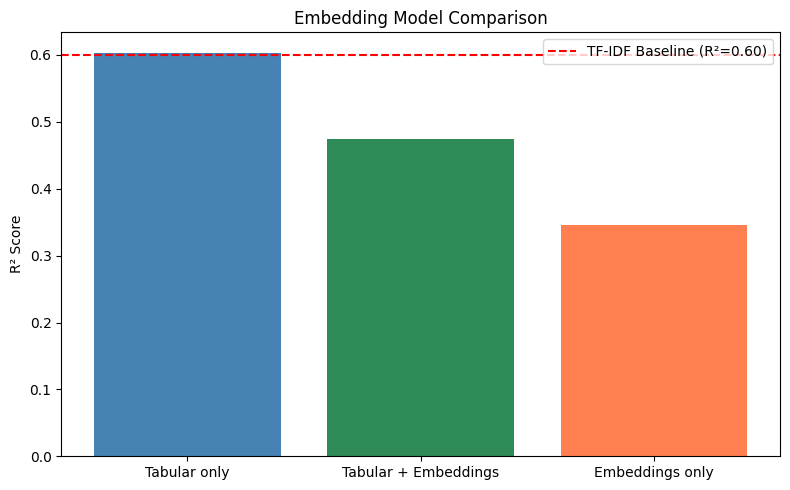

In [33]:
# Comparison chart
models = list(results.keys())
r2_scores = [results[m][0] for m in models]

plt.figure(figsize=(8, 5))
plt.bar(models, r2_scores, color=['steelblue', 'seagreen', 'coral'])
plt.axhline(y=0.60, color='red', linestyle='--', label='TF-IDF Baseline (R²=0.60)')
plt.ylabel('R² Score')
plt.title('Embedding Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# Wine Dataset - Embedding Model: Qwen3-Embedding-0.6B + Random Forest

## Goal
Replace TF-IDF text features with dense sentence embeddings to improve price prediction.

We evaluate 3 scenarios:
1. **Tabular features only** (no text)
2. **Tabular + Embeddings** (combined)
3. **Embeddings only** (text only)

And compare against the TF-IDF baseline.

## Model Used
`Qwen/Qwen3-Embedding-0.6B` — embedding model recommended by supervisor, from HuggingFace.
Each wine description is encoded into a **1024-dimensional vector**.

## Results

| Model | R² | RMSE (£) |
|-------|-----|---------|
| Tabular only | 0.60 | £26.66 |
| Tabular + Embeddings | 0.47 | £28.63 |
| Embeddings only | 0.35 | £30.32 |
| TF-IDF Baseline (all features) | 0.60 | £26.16 |

## Observations
- `Qwen3-Embedding-0.6B` embeddings alone achieve R²=0.35 — better than MiniLM (R²=0.24)
- However, embeddings still do not beat tabular features alone (R²=0.60)
- Adding embeddings to tabular features hurts performance (R²=0.47)
- TF-IDF baseline remains competitive — text alone explains less than tabular features
- **Next step**: investigate why embeddings hurt combined performance, try larger models